In [203]:
import datetime

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch import optim
from torch.nn import MSELoss, L1Loss
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')


In [204]:
plt.rcParams['figure.figsize'] = (10, 7.5)
plt.rcParams['axes.grid'] = False

In [205]:
print(torch.__version__)

2.12.0


In [206]:
torch.manual_seed(42)
np.random.seed(42)

In [207]:
train_df = pd.read_csv('../data/train.csv', index_col=0)
val_df = pd.read_csv('../data/val.csv', index_col=0)
test_df = pd.read_csv('../data/test.csv', index_col=0)

print(train_df.shape, val_df.shape, test_df.shape)

(12285, 5) (3510, 5) (1756, 5)


# Chapter 13 

## 13.1 Creating windows of data
### 13.1.1 Exploring how deep learning models are trained for time series forecasting

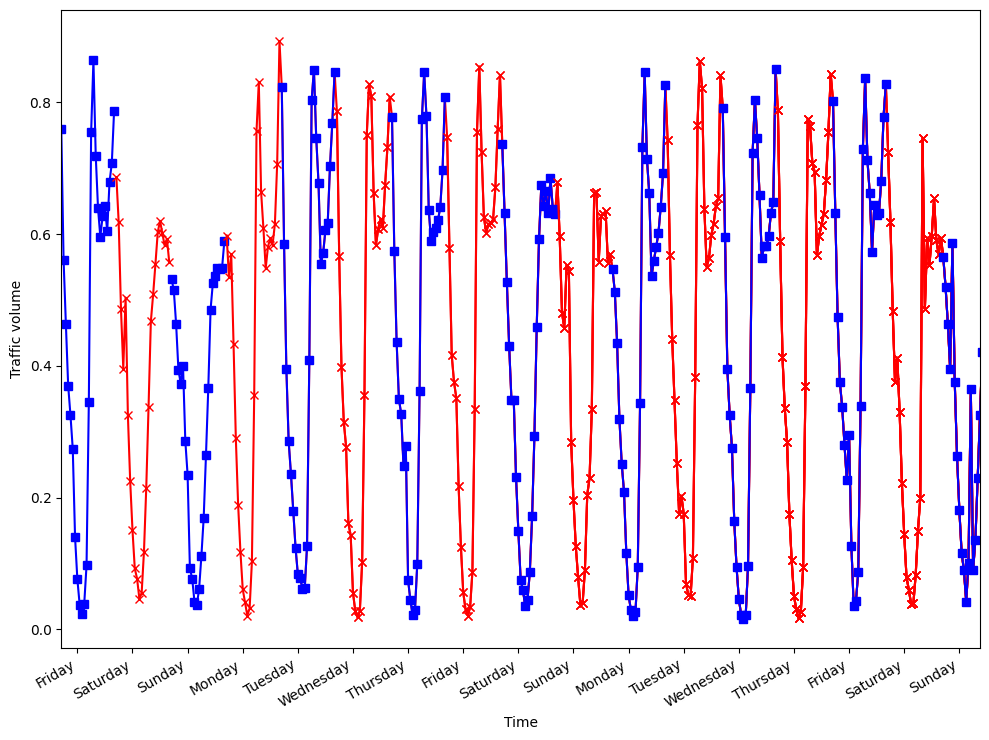

In [208]:
fig, ax = plt.subplots()

for n in range(0,17,2):
    start = 24*n
    stop = 24*(n+1)
    ax.plot(train_df.traffic_volume[start:stop], marker='s', color='blue', label='input')
    ax.plot(train_df.traffic_volume[stop:2*stop], marker='x', color='red', label='label')
ax.set_xlabel('Time')
ax.set_ylabel('Traffic volume')

plt.xticks(np.arange(7, 400, 24), ['Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.xlim(0, 400)

fig.autofmt_xdate()
plt.tight_layout()

### 13.1.2 Implementing the `DataWindow` class 

In [209]:
# 시계열 데이터를 입력(Input)과 정답(Label)으로 나누어
# PyTorch DataLoader를 생성하는 클래스
class DataWindow():
    def __init__(self, input_width, label_width, shift,
                 train_df=train_df, val_df=val_df, test_df=test_df,
                 label_columns=None):

        # 학습 / 검증 / 테스트 데이터
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df

        # 예측할 Label 컬럼
        self.label_columns = label_columns

        # Label 컬럼 이름 -> index
        if label_columns is not None:
            self.label_columns_indices = {
                name: i for i, name in enumerate(label_columns)
            }

        # 전체 컬럼 이름 -> index
        self.column_indices = {
            name: i for i, name in enumerate(train_df.columns)
        }

        # 입력(Input) 길이
        self.input_width = input_width

        # 예측(Label) 길이
        self.label_width = label_width

        # 입력(Input)의 시작 시점과
        # Label의 시작 시점 사이의 시간 간격
        #
        # 예)
        #
        # input_width = 6
        # label_width = 6
        # shift = 1
        #
        # Window : [0 1 2 3 4 5 6]
        # Input  : [0 1 2 3 4 5]
        # Label  :  [1 2 3 4 5 6]
        self.shift = shift

        # 하나의 Window 전체 길이
        #
        # total_window_size
        # = input_width + shift
        #
        # 예)
        #
        # Window : [0 1 2 3 4 5 6]
        self.total_window_size = input_width + shift

        # Input 구간 지정
        #
        # slice(0, input_width)
        #
        # Window : [0 1 2 3 4 5 6]
        # Input  : [0 1 2 3 4 5]
        self.input_slice = slice(0, input_width)

        # Input의 시간 index
        #
        # np.arange(7)
        # -> [0 1 2 3 4 5 6]
        #
        # Input
        # -> [0 1 2 3 4 5]
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        # Label 시작 위치
        #
        # label_start
        # = total_window_size - label_width
        #
        # = 7 - 6
        # = 1
        #
        # Window : [0 1 2 3 4 5 6]
        # Label  :  [1 2 3 4 5 6]
        self.label_start = self.total_window_size - self.label_width

        # Label 구간
        #
        # slice(1, None)
        #
        # None은 끝까지를 의미
        #
        # Window : [0 1 2 3 4 5 6]
        # Label  :  [1 2 3 4 5 6]
        self.labels_slice = slice(self.label_start, None)

        # Label의 시간 index
        #
        # np.arange(7)
        # -> [0 1 2 3 4 5 6]
        #
        # Label
        # -> [1 2 3 4 5 6]
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

    # 하나의 Window를 Input과 Label로 분리
    def _split_to_inputs_labels(self, features):

        # features
        # = [batch, total_window_size, feature]

        # Input 선택
        #
        # -> [batch, input_width, feature]
        inputs = features[:, self.input_slice, :]

        # Label 선택
        #
        # -> [batch, label_width, feature]
        labels = features[:, self.labels_slice, :]

        # 특정 컬럼만 Label로 사용할 경우
        if self.label_columns is not None:

            # labels[:, :, self.column_indices[name]]
            # = 지정한 컬럼 하나 선택
            #
            # -> [batch, label_width]
            #
            # np.stack(..., axis=-1)
            # = 선택한 컬럼들을 마지막(feature) 차원으로 다시 묶음
            #
            # 예)
            #
            # traffic -> [batch, label_width]
            # temp    -> [batch, label_width]
            #
            # ->
            #
            # [batch, label_width, 2]
            labels = np.stack(
                [
                    labels[:, :, self.column_indices[name]]
                    for name in self.label_columns
                ],
                axis=-1
            )

        return inputs, labels

    # Input / Label / Prediction 시각화
    def plot(self, model=None, plot_col='traffic_volume', max_subplots=3):

        # 예시 Batch 가져오기
        inputs, labels = self.sample_batch

        # PyTorch Tensor이면 NumPy 배열로 변환
        if isinstance(inputs, torch.Tensor):
            inputs = inputs.numpy()

        if isinstance(labels, torch.Tensor):
            labels = labels.numpy()

        plt.figure(figsize=(12, 8))

        plot_col_index = self.column_indices[plot_col]

        max_n = min(max_subplots, len(inputs))

        for n in range(max_n):

            plt.subplot(3, 1, n + 1)

            plt.ylabel(f'{plot_col} [scaled]')

            # 입력 시계열
            plt.plot(
                self.input_indices,
                inputs[n, :, plot_col_index],
                label='Inputs',
                marker='.',
                zorder=-10
            )

            if self.label_columns:
                label_col_index = self.label_columns_indices.get(plot_col, None)
            else:
                label_col_index = plot_col_index

            if label_col_index is None:
                continue

            # 실제 Label
            plt.scatter(
                self.label_indices,
                labels[n, :, label_col_index],
                edgecolors='k',
                marker='s',
                label='Labels',
                c='green',
                s=64
            )

            # 모델이 있으면 예측 결과도 출력
            if model is not None:

                model.eval()

                with torch.no_grad():

                    predictions = model(
                        torch.tensor(
                            inputs,
                            dtype=torch.float32
                        )
                    )

                predictions = predictions.numpy()

                plt.scatter(
                    self.label_indices,
                    predictions[n, :, label_col_index],
                    marker='X',
                    edgecolors='k',
                    label='Predictions',
                    c='red',
                    s=64
                )

            if n == 0:
                plt.legend()

        plt.xlabel('Time (h)')

    # DataFrame을 PyTorch DataLoader로 변환
    def make_dataset(self, data):

        # DataFrame -> NumPy 배열
        data = np.array(data, dtype=np.float32)

        # 생성 가능한 Window 개수
        #
        # 예)
        #
        # 데이터 길이 = 100
        # Window 길이 = 7
        #
        # Window 개수 = 94
        n_samples = len(data) - self.total_window_size + 1

        # Sliding Window 생성
        #
        # [0 1 2 3 4 5 6]
        # [1 2 3 4 5 6 7]
        # [2 3 4 5 6 7 8]
        # ...
        #
        # ->
        #
        # features
        # = [window 개수, total_window_size, feature]
        features = np.stack(
            [
                data[i:i + self.total_window_size]
                for i in range(n_samples)
            ],
            axis=0
        )

        # 각 Window를 Input / Label로 분리
        inputs, labels = self._split_to_inputs_labels(features)

        # NumPy -> PyTorch Tensor 변환
        #
        # TensorDataset은
        #
        # (input1, label1)
        # (input2, label2)
        # ...
        #
        # 형태로 데이터를 저장하는 Dataset 클래스
        dataset = TensorDataset(
            torch.tensor(inputs, dtype=torch.float32),
            torch.tensor(labels, dtype=torch.float32),
        )

        # DataLoader 생성
        #
        # TensorDataset으로부터
        #
        # - Mini-batch 생성
        # - Shuffle
        # - 반복(iteration)
        #
        # 기능을 제공한다.
        return DataLoader(
            dataset,
            batch_size=32,
            shuffle=True
        )

    # 학습 DataLoader
    @property
    def train(self):
        return self.make_dataset(self.train_df)

    # 검증 DataLoader
    @property
    def val(self):
        return self.make_dataset(self.val_df)

    # 테스트 DataLoader
    @property
    def test(self):
        return self.make_dataset(self.test_df)

    # 시각화를 위한 예시 Batch 반환
    @property
    def sample_batch(self):

        # 이미 저장된 Batch가 있으면 재사용
        result = getattr(self, '_sample_batch', None)

        # 없으면 학습 DataLoader에서 첫 번째 Batch를 가져와 저장
        if result is None:
            result = next(iter(self.train))
            self._sample_batch = result

        return result

## 13.2 Applying baseline models
### 13.2.1 Single-step baseline model

In [210]:
def evaluate_model(model, data_loader):
    model.eval()
    mse_fn = MSELoss(reduction='sum')
    mae_fn = L1Loss(reduction='sum')
    total_mse, total_mae, n_elements = 0.0, 0.0, 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            preds = model(inputs)
            total_mse += mse_fn(preds, labels).item()
            total_mae += mae_fn(preds, labels).item()
            n_elements += labels.numel()
    return [total_mse / n_elements, total_mae / n_elements]

In [211]:
single_step_window = DataWindow(input_width=1, label_width=1, shift=1, label_columns=['traffic_volume']) 
wide_window = DataWindow(input_width=24, label_width=24, shift=1, label_columns=['traffic_volume'])

In [212]:
# Baseline 모델
#
# 입력값을 그대로 출력하거나,
# 특정 feature만 선택하여 출력하는 기준(Baseline) 모델
class Baseline(nn.Module):
    def __init__(self, label_index=None):
        super().__init__()

        # 예측할 feature의 index
        #
        # None이면 모든 feature 사용
        self.label_index = label_index

    def forward(self, inputs):

        # inputs
        # = [batch_size, input_width, feature]

        # label_index가 없으면
        # 입력을 그대로 출력
        if self.label_index is None:
            return inputs

        # 여러 feature를 예측하는 경우
        elif isinstance(self.label_index, list):

            tensors = []

            for index in self.label_index:

                # 해당 feature만 선택
                #
                # [batch_size, input_width, 1]
                result = inputs[:, :, index:index + 1]

                tensors.append(result)

            # 선택한 feature들을
            # 마지막(feature) 차원으로 결합
            #
            # [batch_size, input_width, feature 개수]
            return torch.cat(tensors, dim=-1)

        # 하나의 feature만 예측하는 경우
        #
        # [batch_size, input_width, 1]
        result = inputs[:, :, self.label_index:self.label_index + 1]

        return result

In [213]:
column_indices = {name: i for i, name in enumerate(train_df.columns)}

baseline_last = Baseline(label_index=column_indices['traffic_volume'])

In [214]:
val_performance = {}
performance = {}

val_performance['Baseline - Last'] = evaluate_model(baseline_last, single_step_window.val)
performance['Baseline - Last'] = evaluate_model(baseline_last, single_step_window.test)

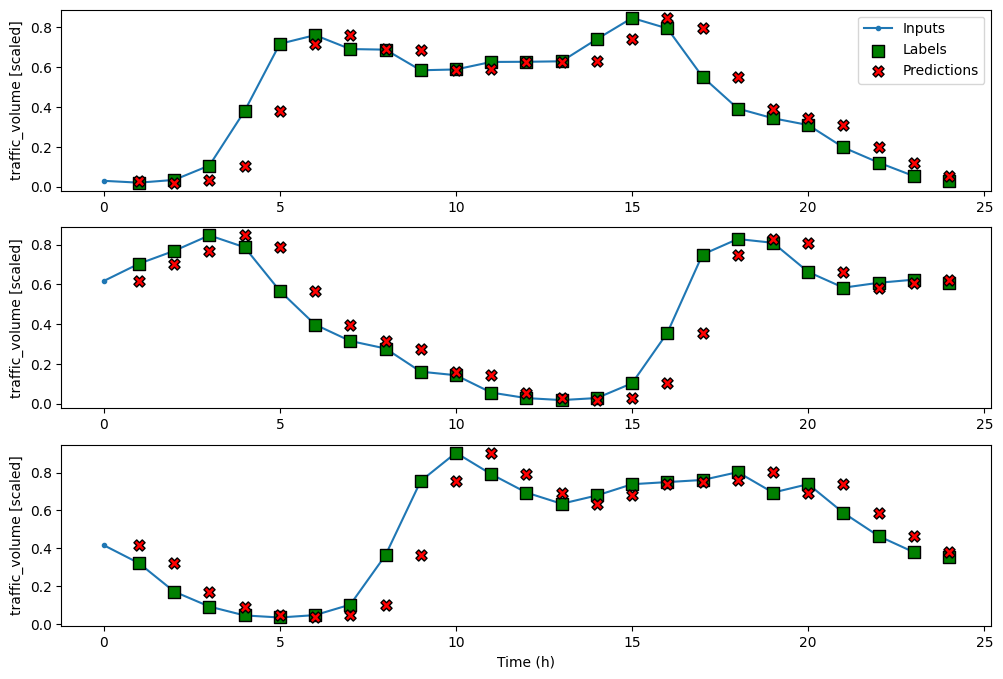

In [215]:
wide_window.plot(baseline_last)

In [216]:
print(performance['Baseline - Last'][1])

0.0812839959761356


### 13.2.2 Multi-step baseline models 

In [217]:
multi_window = DataWindow(input_width=24, label_width=24, shift=24, label_columns=['traffic_volume'])

#### Predicting the last known value 

In [218]:
# Multi-step Last Baseline 모델
#
# 입력 구간의 마지막 시점 값을
# 모든 미래 시점의 예측값으로 그대로 사용하는 Baseline 모델
class MultiStepLastBaseline(nn.Module):
    def __init__(self, label_index=None):
        super().__init__()

        # 예측할 feature의 index
        #
        # None이면 모든 feature 사용
        self.label_index = label_index

    def forward(self, inputs):

        # inputs
        # = [batch_size, input_width, feature]

        # 모든 feature를 예측하는 경우
        if self.label_index is None:

            # 마지막 시점만 선택
            #
            # [batch_size, 1, feature]
            #
            # expand(-1, 24, -1)
            # -> 시간 축으로 24번 복제
            #
            # [batch_size, 24, feature]
            return inputs[:, -1:, :].expand(-1, 24, -1)

        # 특정 feature만 예측하는 경우
        #
        # 마지막 시점의 해당 feature만 선택
        #
        # [batch_size, 1, feature]
        #
        # expand(-1, 24, -1)
        # -> 시간 축으로 24번 복제
        #
        # [batch_size, 24, feature]
        return inputs[:, -1:, self.label_index:self.label_index + 1].expand(-1, 24, -1)

In [219]:
ms_baseline_last = MultiStepLastBaseline(label_index=column_indices['traffic_volume'])

ms_val_performance = {}
ms_performance = {}

ms_val_performance['Baseline - Last'] = evaluate_model(ms_baseline_last, multi_window.val)
ms_performance['Baseline - Last'] = evaluate_model(ms_baseline_last, multi_window.test)

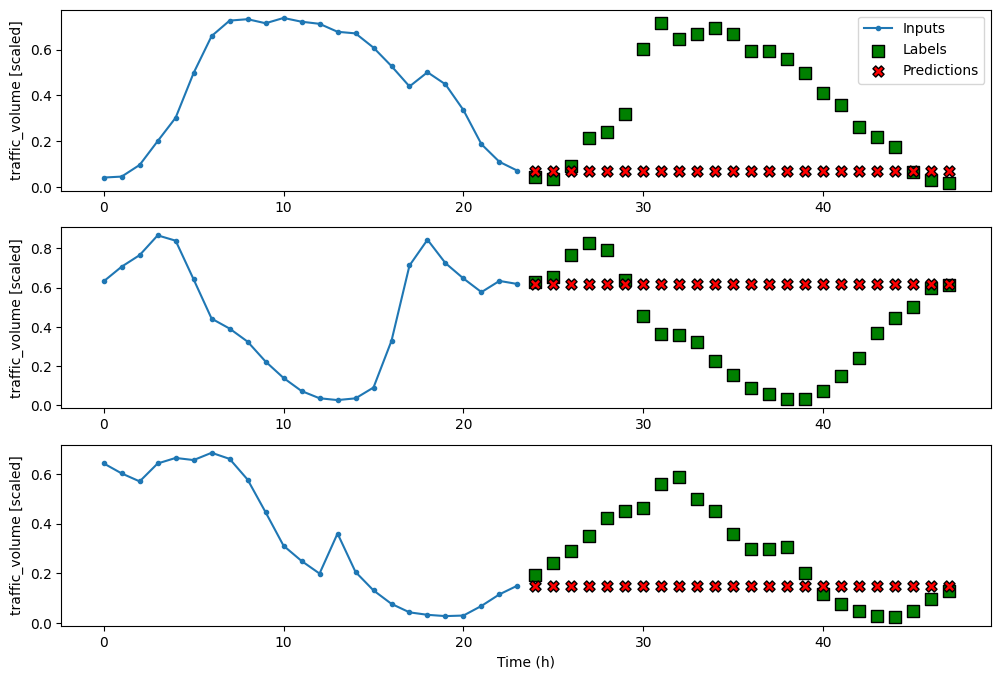

In [220]:
multi_window.plot(ms_baseline_last)

In [221]:
print(ms_performance['Baseline - Last'][1])

0.30206461159230114


#### Repeating the input sequence 

In [222]:
# Repeat Baseline 모델
#
# 입력 구간을 그대로 예측값으로 사용하는 Baseline 모델
# (입력과 Label의 길이가 같은 경우 사용)
class RepeatBaseline(nn.Module):
    def __init__(self, label_index=None):
        super().__init__()

        # 예측할 feature의 index
        self.label_index = label_index

    def forward(self, inputs):

        # inputs
        # = [batch_size, input_width, feature]

        # 지정한 label 컬럼 1개만 선택
        #
        # -> [batch_size, input_width, 1]
        return inputs[:, :, self.label_index:self.label_index + 1]

In [223]:
ms_baseline_repeat = RepeatBaseline(label_index=column_indices['traffic_volume'])

ms_val_performance['Baseline - Repeat'] = evaluate_model(ms_baseline_repeat, multi_window.val)
ms_performance['Baseline - Repeat'] = evaluate_model(ms_baseline_repeat, multi_window.test)

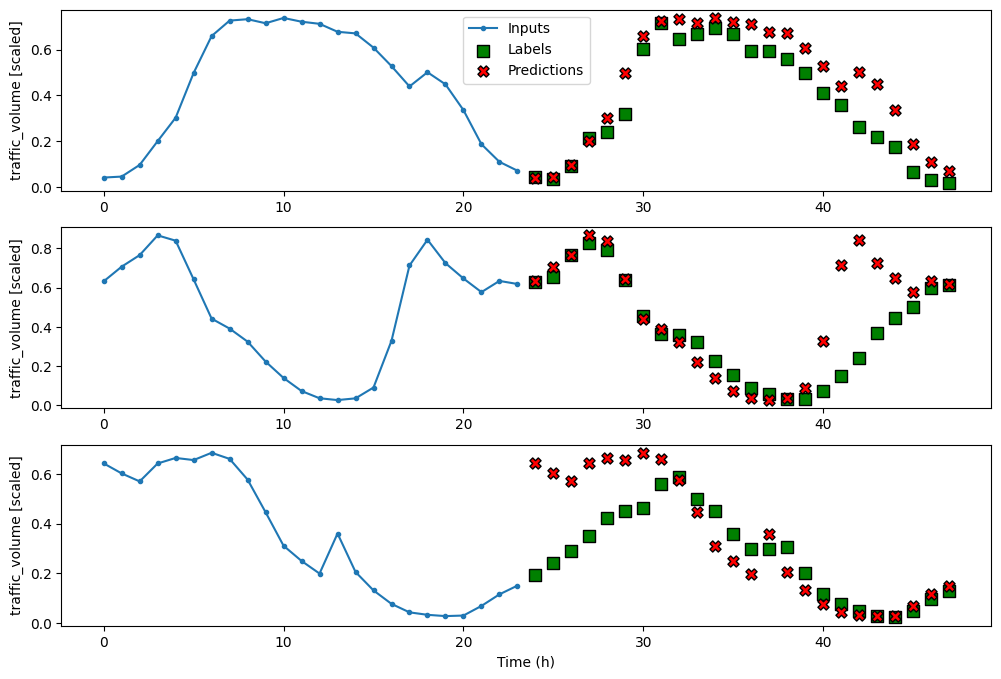

In [224]:
multi_window.plot(ms_baseline_repeat)

In [225]:
print(ms_performance['Baseline - Repeat'][1])

0.0675625697385737


### 13.2.3 Multi-output baseline model 

In [226]:
mo_single_step_window = DataWindow(input_width=1, label_width=1, shift=1, label_columns=['temp','traffic_volume']) 
mo_wide_window = DataWindow(input_width=24, label_width=24, shift=1, label_columns=['temp','traffic_volume'])

In [227]:
print(column_indices['traffic_volume'])
print(column_indices['temp'])

2
0


In [228]:
mo_baseline_last = Baseline(label_index=[0, 2])

mo_val_performance = {}
mo_performance = {}

mo_val_performance['Baseline - Last'] = evaluate_model(mo_baseline_last, mo_wide_window.val)
mo_performance['Baseline - Last'] = evaluate_model(mo_baseline_last, mo_wide_window.test)

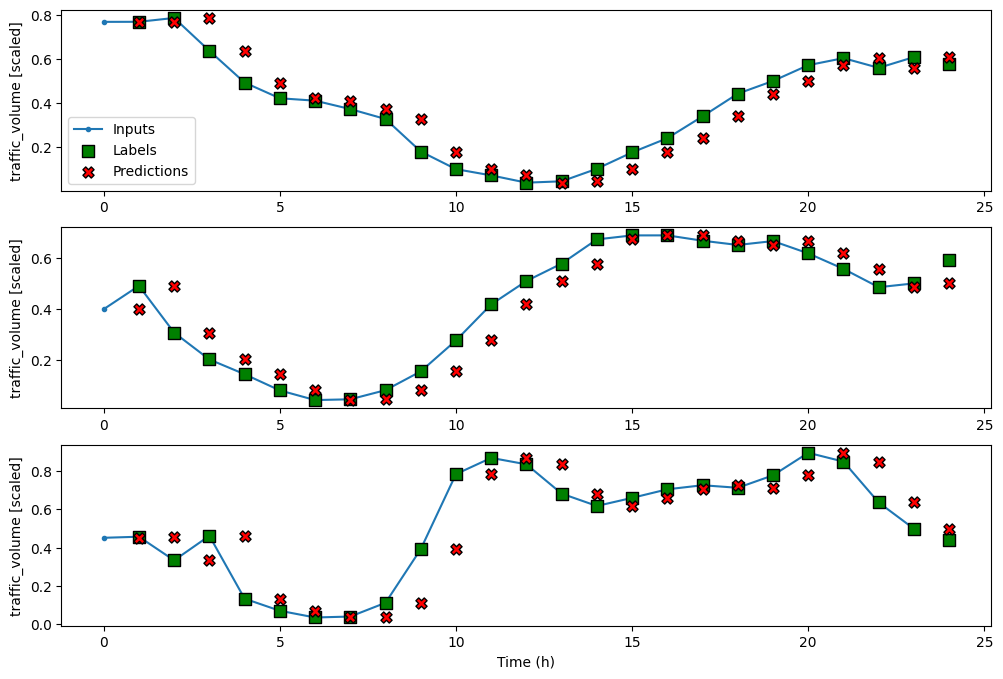

In [229]:
mo_wide_window.plot(mo_baseline_last)

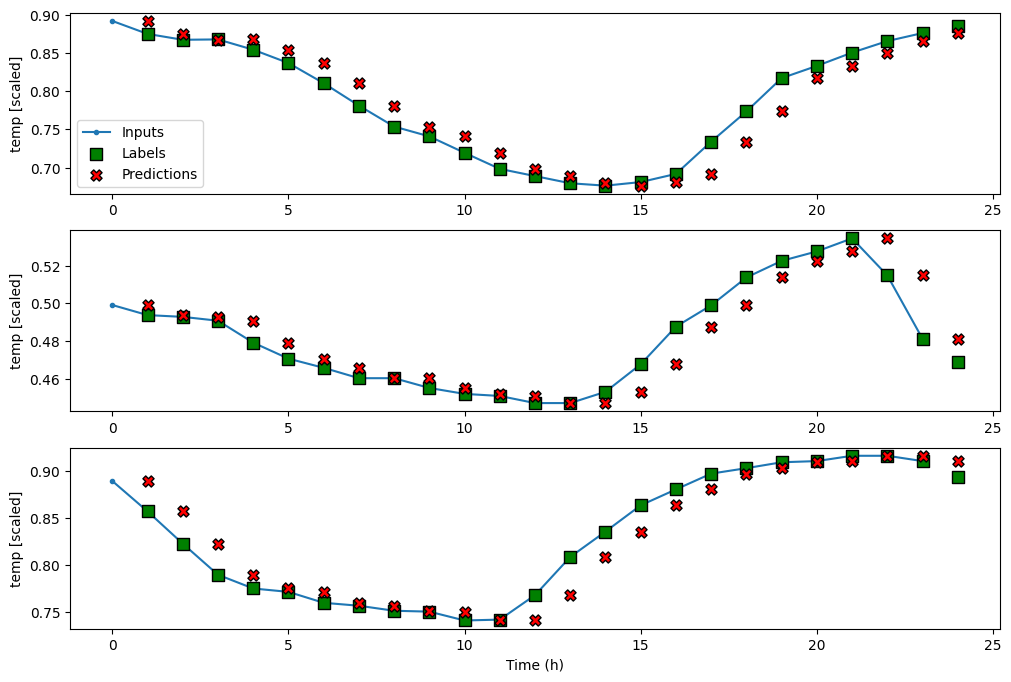

In [230]:
mo_wide_window.plot(model=mo_baseline_last, plot_col='temp')

In [231]:
print(mo_performance['Baseline - Last'][1])

0.047106667148598895


# Chapter 14 

## 14.1 Implementing a linear model
### 14.1.1 Building a single-step linear model

In [232]:
# 모델 학습 함수
#
# Early Stopping을 적용하여 모델을 학습하고
# 학습 과정(loss, MAE)을 반환
def compile_and_fit(model, window, patience=3, max_epochs=50, lr=0.001):
    import time

    # Adam Optimizer 생성
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Loss 함수(MSE)
    mse_fn = MSELoss()

    # 평가 지표(MAE)
    #
    # reduction='sum'
    # -> Batch 전체 오차 합 계산
    mae_fn = L1Loss(reduction='sum')

    # 가장 작은 Validation Loss
    best_val_loss = float('inf')

    # Early Stopping을 위한 카운터
    patience_counter = 0

    # 학습 기록 저장
    history = {
        'loss': [],
        'val_loss': [],
        'mean_absolute_error': [],
        'val_mean_absolute_error': [],
    }

    def _format_step_time(epoch_time, n_steps):
        if n_steps == 0:
            return '0s 0us/step'
        per_step = epoch_time / n_steps
        if epoch_time >= 1.0:
            return f'{epoch_time:.0f}s {per_step * 1000:.0f}ms/step'
        return f'0s {per_step * 1e6:.0f}us/step'

    # 최대 Epoch만큼 반복
    for epoch in range(max_epochs):
        epoch_start = time.perf_counter()

        # ==========================
        # Train
        # ==========================
        model.train()

        train_loss = 0.0
        train_mae = 0.0
        train_n = 0

        train_loader = window.train
        n_batches = len(train_loader)

        # 모든 Mini-batch 학습
        for inputs, labels in train_loader:

            # Gradient 초기화
            optimizer.zero_grad()

            # 모델 예측
            preds = model(inputs)

            # Loss 계산
            loss = mse_fn(preds, labels)

            # 역전파
            loss.backward()

            # 가중치 업데이트
            optimizer.step()

            batch_size = labels.size(0)

            # Loss 누적
            #
            # loss.item()은 Batch 평균 Loss이므로
            # Batch 크기를 곱해 전체 Loss로 변환
            train_loss += loss.item() * batch_size

            # MAE 누적
            train_mae += mae_fn(preds, labels).item()

            # 전체 데이터 개수 누적
            train_n += batch_size

        # ==========================
        # Validation
        # ==========================
        model.eval()

        val_loss = 0.0
        val_mae = 0.0
        val_n = 0

        # Gradient 계산 없이 평가
        with torch.no_grad():

            for inputs, labels in window.val:

                # 모델 예측
                preds = model(inputs)

                batch_size = labels.size(0)

                # Validation Loss 누적
                val_loss += mse_fn(preds, labels).item() * batch_size

                # Validation MAE 누적
                val_mae += mae_fn(preds, labels).item()

                # 전체 데이터 개수 누적
                val_n += batch_size

        # Epoch 평균 Loss 계산
        train_loss /= train_n
        val_loss /= val_n

        # Epoch 평균 MAE 계산
        train_mae /= train_n
        val_mae /= val_n

        # 학습 기록 저장
        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['mean_absolute_error'].append(train_mae)
        history['val_mean_absolute_error'].append(val_mae)

        epoch_time = time.perf_counter() - epoch_start
        time_str = _format_step_time(epoch_time, n_batches)

        print(f'Epoch {epoch + 1}/{max_epochs}')
        print(
            f'{n_batches}/{n_batches} [==============================] - {time_str} - '
            f'loss: {train_loss:.4f} - mean_absolute_error: {train_mae:.4f} - '
            f'val_loss: {val_loss:.4f} - val_mean_absolute_error: {val_mae:.4f}'
        )

        # Validation Loss가 감소하면 최고 성능 갱신
        if val_loss < best_val_loss:

            best_val_loss = val_loss

            # Early Stopping 카운터 초기화
            patience_counter = 0

        else:

            # Validation Loss가 감소하지 않음
            patience_counter += 1

            # patience Epoch 동안 개선되지 않으면 학습 종료
            if patience_counter >= patience:
                break

    # 학습 과정 반환
    return history


In [233]:
n_features = len(train_df.columns)

linear = nn.Sequential(nn.Linear(n_features, 1))

history = compile_and_fit(linear, single_step_window)

val_performance['Linear'] = evaluate_model(linear, single_step_window.val)
performance['Linear'] = evaluate_model(linear, single_step_window.test)

Epoch 1/50
384/384 [==============================] - 0s 144us/step - loss: 0.0389 - mean_absolute_error: 0.1465 - val_loss: 0.0182 - val_mean_absolute_error: 0.1084
Epoch 2/50
384/384 [==============================] - 0s 142us/step - loss: 0.0155 - mean_absolute_error: 0.0954 - val_loss: 0.0150 - val_mean_absolute_error: 0.0961
Epoch 3/50
384/384 [==============================] - 0s 138us/step - loss: 0.0133 - mean_absolute_error: 0.0859 - val_loss: 0.0129 - val_mean_absolute_error: 0.0866
Epoch 4/50
384/384 [==============================] - 0s 140us/step - loss: 0.0119 - mean_absolute_error: 0.0790 - val_loss: 0.0115 - val_mean_absolute_error: 0.0805
Epoch 5/50
384/384 [==============================] - 0s 138us/step - loss: 0.0108 - mean_absolute_error: 0.0743 - val_loss: 0.0104 - val_mean_absolute_error: 0.0745
Epoch 6/50
384/384 [==============================] - 0s 141us/step - loss: 0.0101 - mean_absolute_error: 0.0710 - val_loss: 0.0098 - val_mean_absolute_error: 0.0723
Epoc

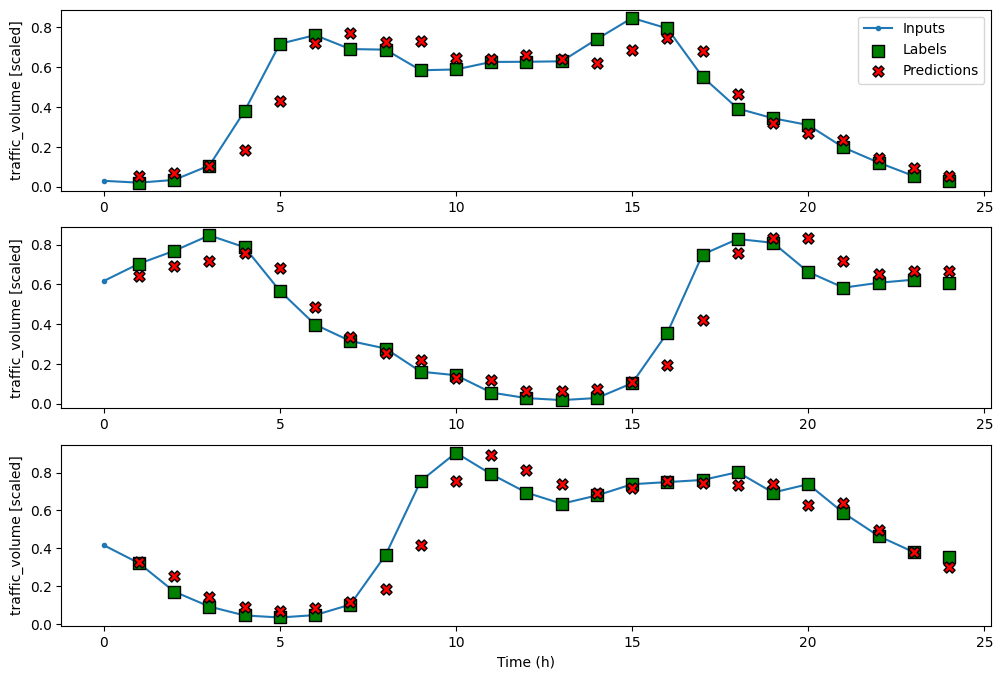

In [234]:
wide_window.plot(linear)

### 14.1.2 Building a mutli-step linear model 

In [235]:
ms_linear = nn.Sequential(nn.Linear(n_features, 1))

history = compile_and_fit(ms_linear, multi_window)

ms_val_performance['Linear'] = evaluate_model(ms_linear, multi_window.val)
ms_performance['Linear'] = evaluate_model(ms_linear, multi_window.test)

Epoch 1/50
383/383 [==============================] - 0s 159us/step - loss: 0.2031 - mean_absolute_error: 8.4381 - val_loss: 0.0329 - val_mean_absolute_error: 3.3303
Epoch 2/50
383/383 [==============================] - 0s 149us/step - loss: 0.0236 - mean_absolute_error: 2.8119 - val_loss: 0.0231 - val_mean_absolute_error: 2.7396
Epoch 3/50
383/383 [==============================] - 0s 149us/step - loss: 0.0192 - mean_absolute_error: 2.4628 - val_loss: 0.0200 - val_mean_absolute_error: 2.4670
Epoch 4/50
383/383 [==============================] - 0s 150us/step - loss: 0.0171 - mean_absolute_error: 2.2419 - val_loss: 0.0187 - val_mean_absolute_error: 2.2950
Epoch 5/50
383/383 [==============================] - 0s 151us/step - loss: 0.0164 - mean_absolute_error: 2.1236 - val_loss: 0.0182 - val_mean_absolute_error: 2.1998
Epoch 6/50
383/383 [==============================] - 0s 151us/step - loss: 0.0161 - mean_absolute_error: 2.0662 - val_loss: 0.0181 - val_mean_absolute_error: 2.1540
Epoc

### 14.1.3 Implementing a multi-output linear model 

In [236]:
mo_linear = nn.Sequential(nn.Linear(n_features, 2))

history = compile_and_fit(mo_linear, mo_single_step_window)

mo_val_performance['Linear'] = evaluate_model(mo_linear, mo_single_step_window.val)
mo_performance['Linear'] = evaluate_model(mo_linear, mo_single_step_window.test)

Epoch 1/50
384/384 [==============================] - 0s 148us/step - loss: 0.2050 - mean_absolute_error: 0.6579 - val_loss: 0.0729 - val_mean_absolute_error: 0.4174
Epoch 2/50
384/384 [==============================] - 0s 145us/step - loss: 0.0508 - mean_absolute_error: 0.3380 - val_loss: 0.0416 - val_mean_absolute_error: 0.3097
Epoch 3/50
384/384 [==============================] - 0s 143us/step - loss: 0.0303 - mean_absolute_error: 0.2553 - val_loss: 0.0260 - val_mean_absolute_error: 0.2402
Epoch 4/50
384/384 [==============================] - 0s 143us/step - loss: 0.0192 - mean_absolute_error: 0.1989 - val_loss: 0.0173 - val_mean_absolute_error: 0.1915
Epoch 5/50
384/384 [==============================] - 0s 144us/step - loss: 0.0133 - mean_absolute_error: 0.1599 - val_loss: 0.0124 - val_mean_absolute_error: 0.1566
Epoch 6/50
384/384 [==============================] - 0s 144us/step - loss: 0.0101 - mean_absolute_error: 0.1334 - val_loss: 0.0096 - val_mean_absolute_error: 0.1300
Epoc

## 14.2 Implementing a deep neural network
### 14.2.1 Implementing a deep neural network as a single-step model

In [237]:
dense = nn.Sequential(
    nn.Linear(n_features, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
)

history = compile_and_fit(dense, single_step_window)

val_performance['Dense'] = evaluate_model(dense, single_step_window.val)
performance['Dense'] = evaluate_model(dense, single_step_window.test)

Epoch 1/50
384/384 [==============================] - 0s 336us/step - loss: 0.0123 - mean_absolute_error: 0.0756 - val_loss: 0.0050 - val_mean_absolute_error: 0.0510
Epoch 2/50
384/384 [==============================] - 0s 339us/step - loss: 0.0041 - mean_absolute_error: 0.0473 - val_loss: 0.0029 - val_mean_absolute_error: 0.0404
Epoch 3/50
384/384 [==============================] - 0s 348us/step - loss: 0.0031 - mean_absolute_error: 0.0411 - val_loss: 0.0032 - val_mean_absolute_error: 0.0438
Epoch 4/50
384/384 [==============================] - 0s 410us/step - loss: 0.0028 - mean_absolute_error: 0.0382 - val_loss: 0.0029 - val_mean_absolute_error: 0.0407
Epoch 5/50
384/384 [==============================] - 0s 315us/step - loss: 0.0026 - mean_absolute_error: 0.0366 - val_loss: 0.0021 - val_mean_absolute_error: 0.0340
Epoch 6/50
384/384 [==============================] - 0s 321us/step - loss: 0.0024 - mean_absolute_error: 0.0352 - val_loss: 0.0019 - val_mean_absolute_error: 0.0318
Epoc

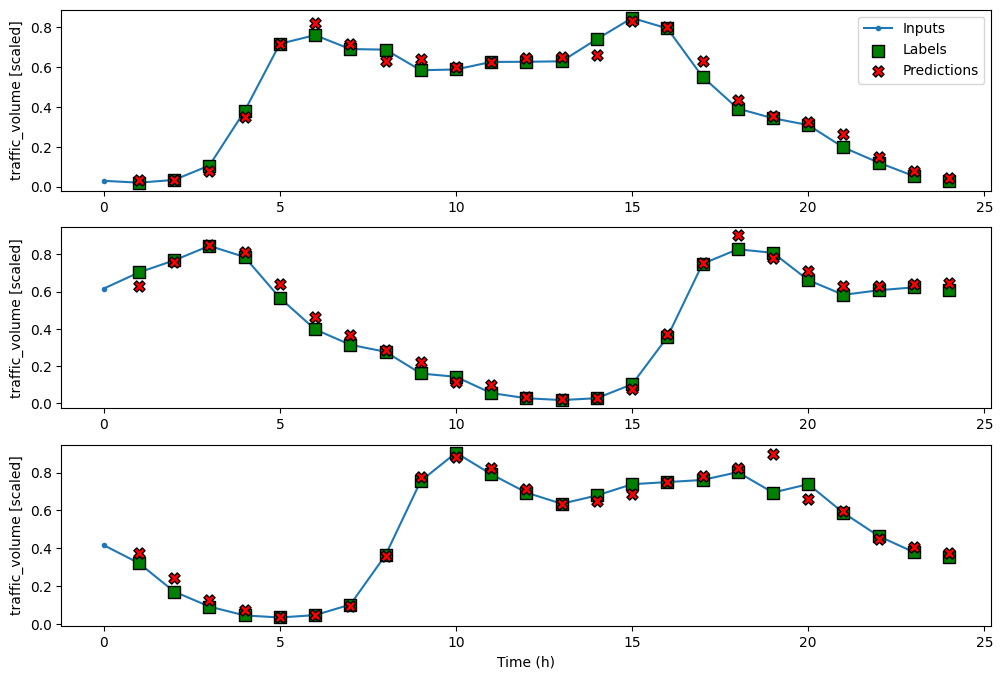

In [238]:
wide_window.plot(dense)

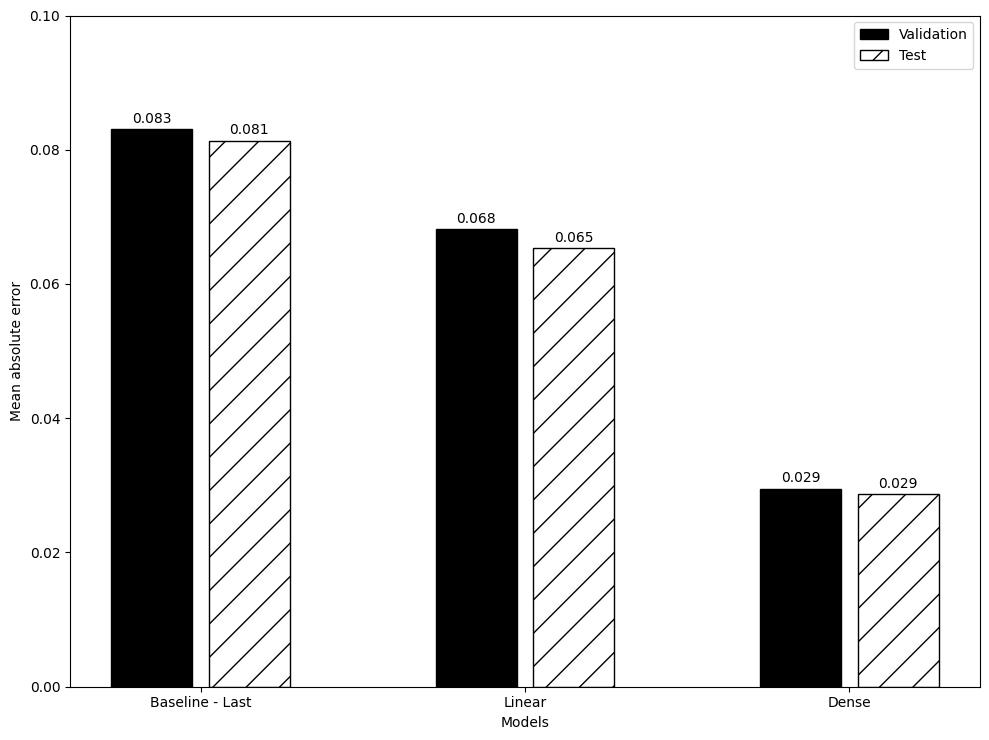

In [239]:
mae_val = [v[1] for v in val_performance.values()]
mae_test = [v[1] for v in performance.values()]

x = np.arange(len(performance))

fig, ax = plt.subplots()
ax.bar(x - 0.15, mae_val, width=0.25, color='black', edgecolor='black', label='Validation')
ax.bar(x + 0.15, mae_test, width=0.25, color='white', edgecolor='black', hatch='/', label='Test')
ax.set_ylabel('Mean absolute error')
ax.set_xlabel('Models')

for index, value in enumerate(mae_val):
    plt.text(x=index - 0.15, y=value+0.001, s=str(round(value, 3)), ha='center')
    
for index, value in enumerate(mae_test):
    plt.text(x=index + 0.15, y=value+0.001, s=str(round(value, 3)), ha='center')

plt.ylim(0, 0.1)
plt.xticks(ticks=x, labels=performance.keys())
plt.legend(loc='best')
plt.tight_layout()

### 14.2.2 Implementing a deep neural network as a multi-step model 

In [240]:
ms_dense = nn.Sequential(
    nn.Linear(n_features, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
)

history = compile_and_fit(ms_dense, multi_window)

ms_val_performance['Dense'] = evaluate_model(ms_dense, multi_window.val)
ms_performance['Dense'] = evaluate_model(ms_dense, multi_window.test)

Epoch 1/50
383/383 [==============================] - 0s 664us/step - loss: 0.0211 - mean_absolute_error: 2.3480 - val_loss: 0.0163 - val_mean_absolute_error: 2.0419
Epoch 2/50
383/383 [==============================] - 0s 711us/step - loss: 0.0141 - mean_absolute_error: 1.8905 - val_loss: 0.0157 - val_mean_absolute_error: 1.9928
Epoch 3/50
383/383 [==============================] - 0s 654us/step - loss: 0.0137 - mean_absolute_error: 1.8783 - val_loss: 0.0153 - val_mean_absolute_error: 1.9439
Epoch 4/50
383/383 [==============================] - 0s 667us/step - loss: 0.0135 - mean_absolute_error: 1.8658 - val_loss: 0.0156 - val_mean_absolute_error: 2.0842
Epoch 5/50
383/383 [==============================] - 0s 666us/step - loss: 0.0133 - mean_absolute_error: 1.8587 - val_loss: 0.0151 - val_mean_absolute_error: 2.0268
Epoch 6/50
383/383 [==============================] - 0s 666us/step - loss: 0.0131 - mean_absolute_error: 1.8409 - val_loss: 0.0147 - val_mean_absolute_error: 1.9741
Epoc

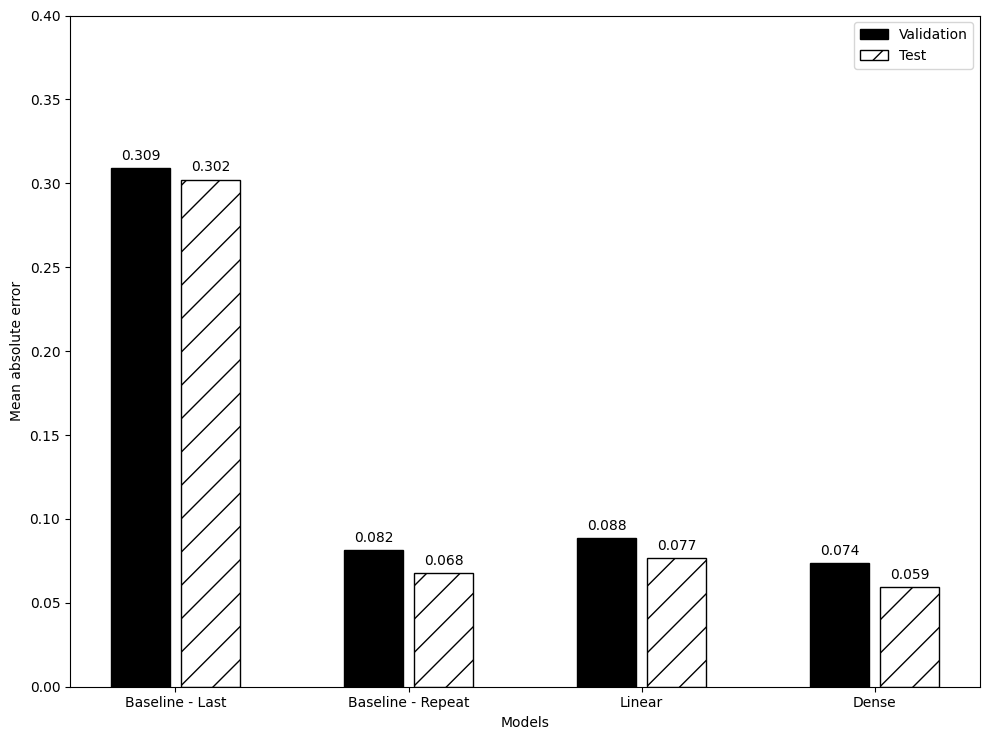

In [241]:
ms_mae_val = [v[1] for v in ms_val_performance.values()]
ms_mae_test = [v[1] for v in ms_performance.values()]

x = np.arange(len(ms_performance))

fig, ax = plt.subplots()
ax.bar(x - 0.15, ms_mae_val, width=0.25, color='black', edgecolor='black', label='Validation')
ax.bar(x + 0.15, ms_mae_test, width=0.25, color='white', edgecolor='black', hatch='/', label='Test')
ax.set_ylabel('Mean absolute error')
ax.set_xlabel('Models')

for index, value in enumerate(ms_mae_val):
    plt.text(x=index - 0.15, y=value+0.005, s=str(round(value, 3)), ha='center')
    
for index, value in enumerate(ms_mae_test):
    plt.text(x=index + 0.15, y=value+0.005, s=str(round(value, 3)), ha='center')

plt.ylim(0, 0.4)
plt.xticks(ticks=x, labels=ms_performance.keys())
plt.legend(loc='best')
plt.tight_layout()

### 14.2.3 Implementing a deep neural network as a multi-output model 

In [242]:
mo_dense = nn.Sequential(
    nn.Linear(n_features, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 2),
)

history = compile_and_fit(mo_dense, mo_single_step_window)

mo_val_performance['Dense'] = evaluate_model(mo_dense, mo_single_step_window.val)
mo_performance['Dense'] = evaluate_model(mo_dense, mo_single_step_window.test)

Epoch 1/50
384/384 [==============================] - 0s 328us/step - loss: 0.0205 - mean_absolute_error: 0.1758 - val_loss: 0.0038 - val_mean_absolute_error: 0.0805
Epoch 2/50
384/384 [==============================] - 0s 320us/step - loss: 0.0034 - mean_absolute_error: 0.0724 - val_loss: 0.0025 - val_mean_absolute_error: 0.0640
Epoch 3/50
384/384 [==============================] - 0s 323us/step - loss: 0.0025 - mean_absolute_error: 0.0629 - val_loss: 0.0018 - val_mean_absolute_error: 0.0550
Epoch 4/50
384/384 [==============================] - 0s 322us/step - loss: 0.0021 - mean_absolute_error: 0.0566 - val_loss: 0.0015 - val_mean_absolute_error: 0.0519
Epoch 5/50
384/384 [==============================] - 0s 321us/step - loss: 0.0019 - mean_absolute_error: 0.0530 - val_loss: 0.0013 - val_mean_absolute_error: 0.0473
Epoch 6/50
384/384 [==============================] - 0s 324us/step - loss: 0.0018 - mean_absolute_error: 0.0513 - val_loss: 0.0014 - val_mean_absolute_error: 0.0504
Epoc

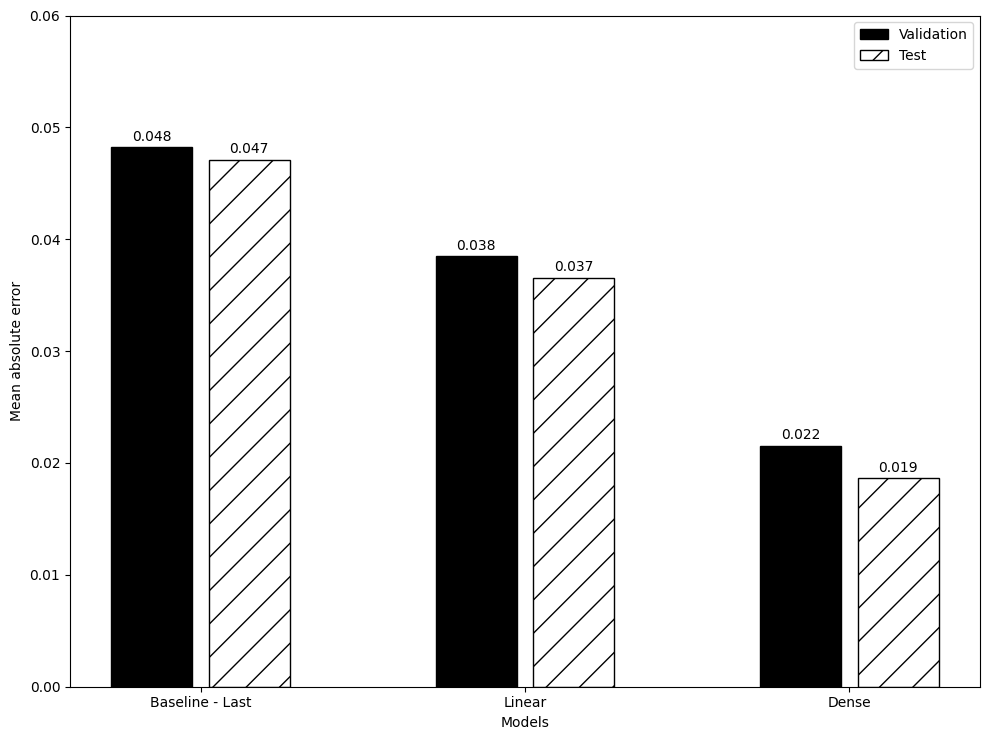

In [243]:
mo_mae_val = [v[1] for v in mo_val_performance.values()]
mo_mae_test = [v[1] for v in mo_performance.values()]

x = np.arange(len(mo_performance))

fig, ax = plt.subplots()
ax.bar(x - 0.15, mo_mae_val, width=0.25, color='black', edgecolor='black', label='Validation')
ax.bar(x + 0.15, mo_mae_test, width=0.25, color='white', edgecolor='black', hatch='/', label='Test')
ax.set_ylabel('Mean absolute error')
ax.set_xlabel('Models')

for index, value in enumerate(mo_mae_val):
    plt.text(x=index - 0.15, y=value+0.0006, s=str(round(value, 3)), ha='center')
    
for index, value in enumerate(mo_mae_test):
    plt.text(x=index + 0.15, y=value+0.0006, s=str(round(value, 3)), ha='center')

plt.ylim(0, 0.06)
plt.xticks(ticks=x, labels=mo_performance.keys())
plt.legend(loc='best')
plt.tight_layout()